# The sample

A miniature of AI-GenBench: **144 authentic + 144 fake** images, exactly 50/50, with 4 images from
each of the 36 benchmark generators.

It is partitioned into a **train** and a **val** half, 72 + 72 each way, stratified so every
generator contributes 2 images to each side and the three authentic sources keep their proportions.
A per-family score model cannot be calibrated on a family that landed entirely on one side, which is
what the stratification buys.

Building it is a one-time job and lives in [`imports/sample/`](imports/sample/) —
`authentic.py` pulls COCO / LAION / RAISE, `fakes.py` pulls the synthetic half from the benchmark's
parquet, and both write the `split` column through the same `common.assign_splits`. This notebook
just reads what they produced.

See the README for the caveats that matter before drawing conclusions from it — the important one
being that the two halves are **not content-paired**.

## Load

Read the two sets of images (real and fake) from disk into memory.

In [1]:
import sys

sys.path.insert(0, "imports/sample")

import pandas as pd

import common
import imaging

REBUILD = False  # flip to True to re-import even when data/ is already populated

In [2]:
if REBUILD or not common.sample_exists():
    import authentic
    import fakes

    authentic.main()
    print()
    fakes.main()
else:
    print("sample already imported — set REBUILD = True to rebuild")

sample = common.load_sample()
print(f"\n{len(sample)} rows")

sample already imported — set REBUILD = True to rebuild

288 rows


## Balance

Count how many real vs. fake images to confirm the 144/144 split, and check the same balance holds
inside each of train and val.

In [3]:
counts = sample["label"].value_counts().sort_index()
print(f"authentic (label 0): {counts.get(0, 0)}")
print(f"fake      (label 1): {counts.get(1, 0)}")
assert counts.get(0, 0) == counts.get(1, 0), "halves are not balanced"

by_split = pd.crosstab(sample["split"], sample["label"])
assert (by_split == len(sample) // 4).all().all(), f"train/val is not 50/50 within each class:\n{by_split}"
print()
print(by_split.to_string())

print()
print(sample.groupby(["label", "origin_dataset"]).size().to_string())

authentic (label 0): 144
fake      (label 1): 144

label   0   1
split        
train  72  72
val    72  72

label  origin_dataset       
0      COCO2017                 68
       LAION-400M               68
       RAISE                     8
1      Aeroblade                 2
       Artifact                 66
       DDMD                     14
       DMimageDetection/test     6
       DRCT                      3
       ELSA_D3/train             7
       ELSA_D3/valid             4
       Forensynths/test         16
       GenImage/train           10
       Imaginet                  5
       Polardiffshield           1
       SFHQ-T2I                  8
       Synthbuster               2


## Splits

The train/val partition. Two things have to hold: no image is on both sides, and no generator is
missing from either side — a generator absent from `train` has no score model, one absent from `val`
has nothing to check it against.

In [4]:
train_ids = set(sample.loc[sample["split"] == "train", "file_id"])
val_ids = set(sample.loc[sample["split"] == "val", "file_id"])
assert not train_ids & val_ids, f"{len(train_ids & val_ids)} file_ids appear in both splits"
print(f"{len(train_ids)} train + {len(val_ids)} val, disjoint")

per_split = sample[sample["label"] == 1].groupby(["split", "generator"]).size()
assert (per_split == 2).all(), f"uneven generator coverage:\n{per_split[per_split != 2]}"
print(f"all {per_split.index.get_level_values('generator').nunique()} generators: "
      f"2 train + 2 val")

print()
print(pd.crosstab(sample[sample["label"] == 0]["origin_dataset"], sample["split"]).to_string())

144 train + 144 val, disjoint
all 36 generators: 2 train + 2 val

split           train  val
origin_dataset            
COCO2017           34   34
LAION-400M         34   34
RAISE               4    4


## Generator coverage

Every generator should appear exactly four times. `release_date` is the benchmark's own registry —
the spine of the G≤T construction — and it stops at 2024-08, which is the coverage gap newer
generators would have to fill.

In [5]:
fakes_only = sample[sample["label"] == 1]
per_generator = fakes_only.groupby(["release_date", "generator"]).size()

print(f"{len(per_generator)} generators, {per_generator.min()}-{per_generator.max()} images each")
print(f"{fakes_only['release_date'].min()} to {fakes_only['release_date'].max()}")
print()
print(per_generator.to_string())

36 generators, 4-4 images each
2017-03-30 to 2024-08-02

release_date  generator                   
2017-03-30    CycleGAN                        4
2017-07-28    Cascaded Refinement Networks    4
2017-10-27    ProGAN                          4
2017-11-24    StarGAN                         4
2018-06-10    SN-PatchGAN                     4
2018-09-28    BigGAN                          4
2018-11-29    IMLE                            4
2018-12-12    StyleGAN1                       4
2019-03-18    GauGAN                          4
2019-12-03    StyleGAN2                       4
2020-06-19    DDPM                            4
2020-11-27    CIPS                            4
2020-12-17    VQGAN                           4
2021-03-01    GANformer                       4
2021-05-11    ADM                             4
2021-06-23    StyleGAN3                       4
2021-09-15    LaMa                            4
2021-09-30    FaceSynthetics                  4
2021-11-01    ProjectedGAN          

## Compression parity

Check that the two halves are compressed with the same JPEG compression settings.

Both halves are normalized by the same `prepare_image`, so they must share one quantization table.
If they ever diverge, a detector could separate the classes on compression history alone.

In [6]:
imaging.check_parity(common.AUTHENTIC_DIR, common.FAKES_DIR)

print()
print("fake source containers, before normalizing:")
print(fakes_only["source_format"].value_counts().to_string())

authentics qtab0[:8] = [2, 1, 1, 2, 2, 4, 5, 6]  (144 images)
fakes      qtab0[:8] = [2, 1, 1, 2, 2, 4, 5, 6]  (144 images)
both halves share one quantization table -- compression history is not a class cue

fake source containers, before normalizing:
source_format
JPEG    77
PNG     66
WEBP     1


## Preview

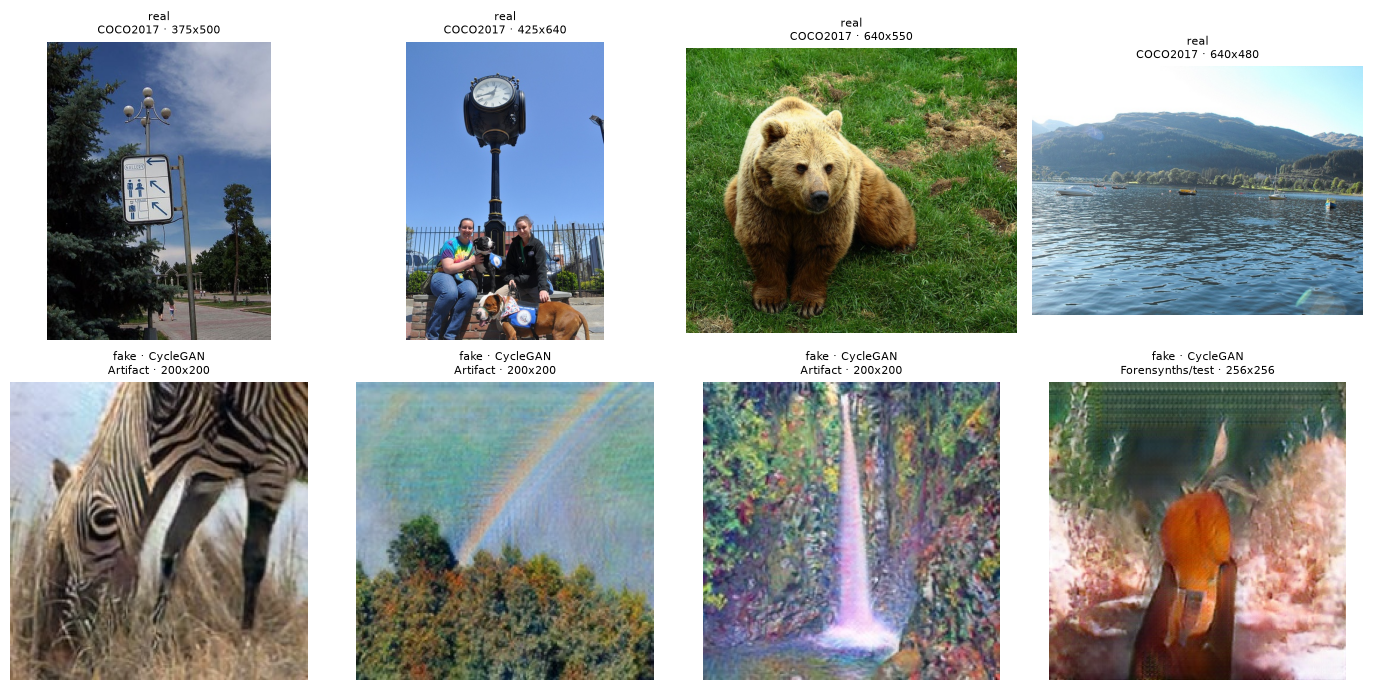

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

shown = (
    sample[sample["label"] == 0].head(4).to_dict("records")
    + fakes_only.head(4).to_dict("records")
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, row in zip(axes.flat, shown):
    ax.imshow(Image.open(common.PROJECT_ROOT / row["path"]))
    kind = "real" if row["label"] == 0 else f'fake · {row["generator"]}'
    ax.set_title(f'{kind}\n{row["origin_dataset"]} · {row["width"]}x{row["height"]}', fontsize=8)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

## The manifest

In [8]:
sample[["file_id", "label", "generator", "origin_dataset", "split"]].head(10)

,file_id,label,generator,origin_dataset,split
0,COCO2017_train/13992,0,,COCO2017,val
1,COCO2017_train/571920,0,,COCO2017,val
2,COCO2017_train/539678,0,,COCO2017,val
3,COCO2017_train/185915,0,,COCO2017,train
4,COCO2017_train/398869,0,,COCO2017,train
5,COCO2017_train/498587,0,,COCO2017,train
6,COCO2017_train/278938,0,,COCO2017,val
7,COCO2017_train/461517,0,,COCO2017,val
8,COCO2017_train/262399,0,,COCO2017,train
9,COCO2017_train/337416,0,,COCO2017,val
